# 022 比较实验与统计不确定性

## Goal
固定数据上八个合成种子配对，如何区分方法效果、区间假设和选择好运？主表人为设定，不是真实训练成绩。先修018与021，核心标准库、离线CPU。

## Setup
在本单元目录重启内核、顺序运行。固定图文仅针对随附默认配置、计划和种子表；第一格会先验证输入与已有结果，拒绝用自定义结果套固定教学图。自定义实验应另存。

In [1]:
from pathlib import Path
from fractions import Fraction as F
from itertools import product
from IPython.display import display,Image
import math,json,sys
import experiment as ex
ex.require_teaching_inputs()
print("Python",sys.version.split()[0])

Python 3.12.14


## Steps
### 1 先读主比较
效果A−B、单位百分点、正值利于B、配对单位是固定数据上的训练随机状态。计划随教材提供，不能证明现实中的外部预注册。

In [2]:
plan=json.loads(Path("data/plan.json").read_text())
print(plan)
assert plan["paired_unit"]=="training_seed_on_fixed_data"
rows=ex.read_rows(Path("data/seed_scores.csv"))
a=[r[1] for r in rows];b=[r[2] for r in rows];d=[x-y for x,y in zip(a,b)]
print("differences",d)

{'comparison': ['A', 'B'], 'metric': 'error_percent', 'effect': 'A_minus_B_percentage_points', 'paired_unit': 'training_seed_on_fixed_data', 'seed_ids': [0, 1, 2, 3, 4, 5, 6, 7], 'selection': 'none_all_eight_pairs_reported', 'intervals': ['paired_t7_rounded', 'percentile_bootstrap'], 'bootstrap_unit': 'whole_seed_pair', 'practical_margin_points': 3}
differences [2, 4, 0, 6, -2, 4, 2, 0]


### 2 以有理数核对方差
采用平方和减均值平方的独立等式，对比函数结果。

In [3]:
n=len(d);mean=F(sum(d),n)
variance=(sum(F(x*x) for x in d)-F(sum(d)**2,n))/(n-1)
summary=ex.paired_summary(a,b)
assert mean==2 and variance==F(48,7)
assert F(summary["exact_variance"])==variance
print("mean",mean,"variance",variance,"SE",summary["paired_se"],"wrong unpaired formula",summary["unpaired_formula_se"])

mean 2 variance 48/7 SE 0.9258200997725514 wrong unpaired formula 4.605896841472431


### 3 观察全部配对
不删差种子，不分别排序两列。

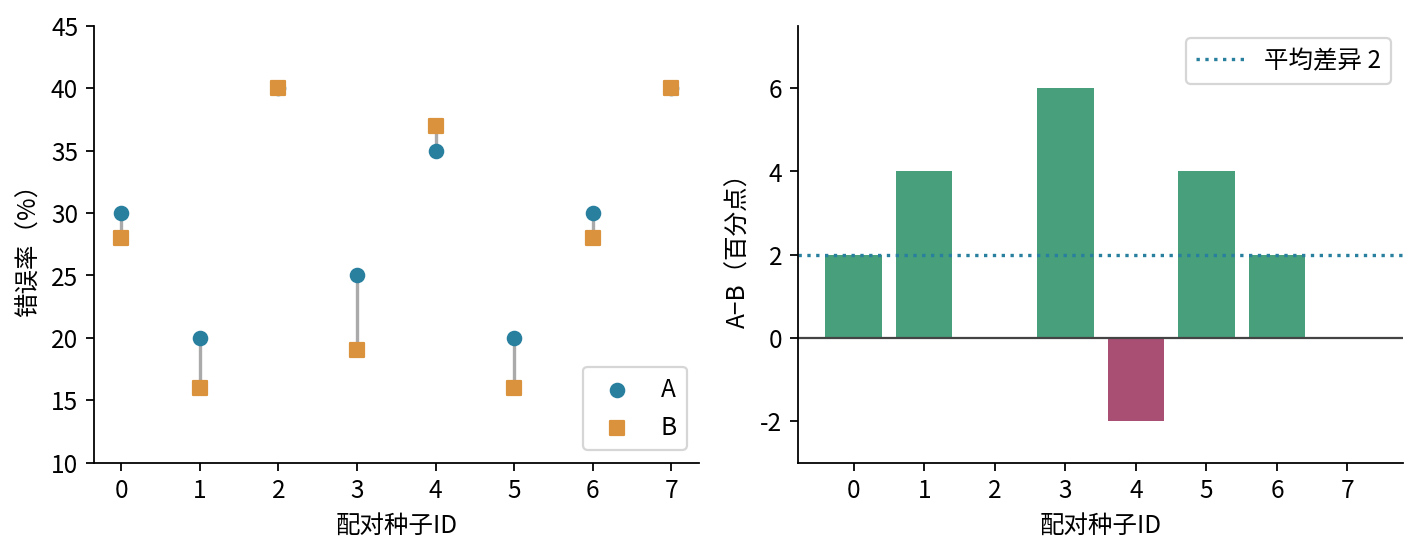

In [4]:
display(Image(filename="figures/02_pairs.png",width=750))

### 4 t与正态近似路径
自由度7的临界值2.365是表格舍入。独立正态差异条件没有由这八个合成数得到证明；不能择优挑区间。

In [5]:
t=ex.paired_t7(d);normal=ex.interval(d,1.96)
assert t[0]<0<normal[0]
print("rounded t interval",t,"normal approximation",normal)

rounded t interval [-0.18956453596208434, 4.189564535962084] normal approximation [0.1853926044457992, 3.8146073955542006]


### 5 一次保留配对的重采样
共同抽索引，等价于抽差异列；重复索引不创造新观察。

In [6]:
ids=[3,3,0,4,1,6,2,7]
chosen=[a[i]-b[i] for i in ids]
assert F(sum(chosen),8)==F(9,4)
print(chosen,"mean",F(sum(chosen),8))

[6, 6, 2, -2, 4, 2, 0, 0] mean 9/4


### 6 精确经验bootstrap
整数卷积保留全部8^8有序抽样的计数，消除Monte Carlo误差，但没有消除真实分布未知的统计近似误差。

In [7]:
exact=ex.exact_bootstrap(d)
assert exact["ordered_samples"]==8**8
assert exact["variance"]=="3/4"
assert exact["percentile_95"]==["1/4","15/4"]
print({k:v for k,v in exact.items() if k!="counts"})

{'ordered_samples': 16777216, 'mean': '2', 'variance': '3/4', 'percentile_95': ['1/4', '15/4']}


### 7 实际执行全部实验
4000次bootstrap、6000行选择/复测和九类稀有情况。只写notebook_outputs，不改变原输入。

In [8]:
result=ex.run(Path("notebook_outputs"))
print("Monte Carlo endpoints",result["bootstrap_monte_carlo_95"])
for row in result["selection_summary"]:print(row)

Monte Carlo endpoints ['1/4', '15/4']
{'candidates': 1, 'mean_selected_validation': -0.017, 'mean_independent_test': -0.019, 'theoretical_selected_mean': '0', 'familywise_05_independent': '1/20', 'bonferroni_level': '1/20'}
{'candidates': 5, 'mean_selected_validation': 0.941, 'mean_independent_test': 0.053, 'theoretical_selected_mean': '15/16', 'familywise_05_independent': '723901/3200000', 'bonferroni_level': '1/100'}
{'candidates': 20, 'mean_selected_validation': 1.0, 'mean_independent_test': 0.01, 'theoretical_selected_mean': '524287/524288', 'familywise_05_independent': '67267626542454041806644399/104857600000000000000000000', 'bonferroni_level': '1/400'}


### 8 精确bootstrap也可能覆盖失败
真实差异20×Bernoulli(0.01)的均值0.2，八个独立观察大多全零。

all zero 0.9227446944279201 exact coverage 0.077201372250882


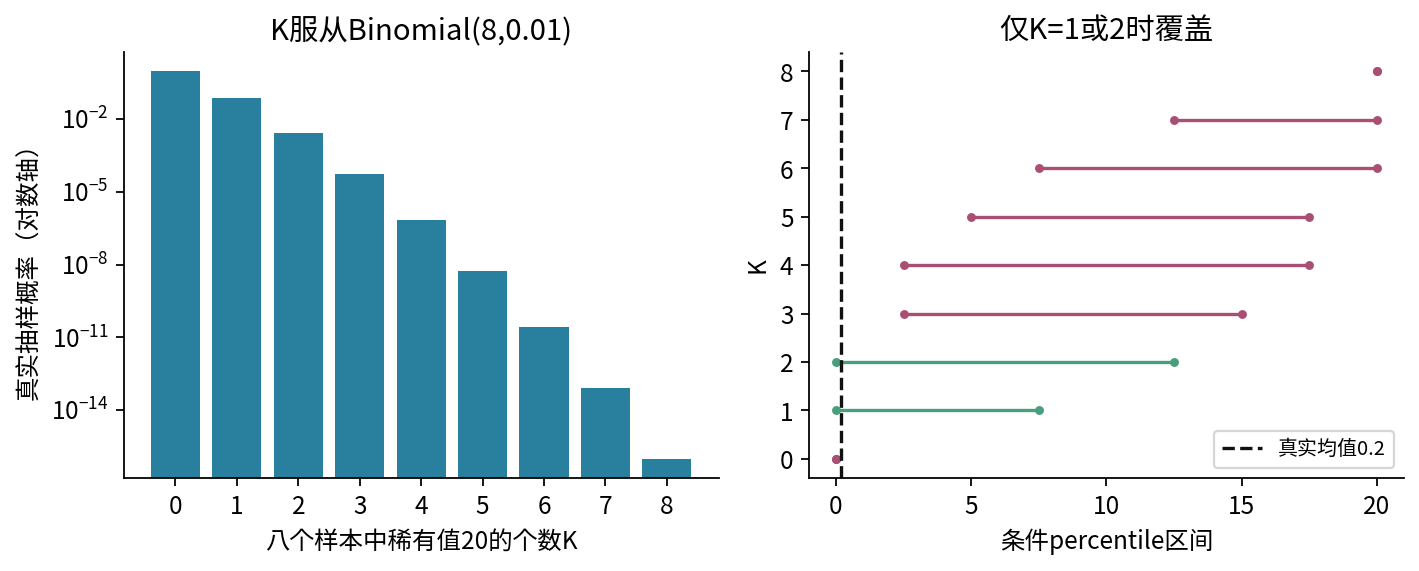

In [9]:
coverage,rare=ex.rare_coverage()
assert sum(F(row["sample_probability"]) for row in rare)==1
assert [row["positive_count"] for row in rare if row["covers_true_mean"]]==[1,2]
assert coverage==8*F(1,100)*F(99,100)**7+28*F(1,100)**2*F(99,100)**6
print("all zero",float(F(99,100)**8),"exact coverage",float(coverage))
display(Image(filename="figures/06_rare_failure.png",width=750))

### 9 重复行不是独立实体
相同均值下，误用32行独立会缩小标准误。

In [10]:
entities=[-2,0,2,4];copied=[x for x in entities for _ in range(8)]
assert ex.moments(entities)[1]/4==F(5,3)
assert ex.moments(copied)[1]/32==F(5,31)
print("entity SE squared",F(5,3),"wrong row SE squared",F(5,31))

entity SE squared 5/3 wrong row SE squared 5/31


### 10 选择纯噪声
枚举3候选的8个验证向量；独立复测对每个选中候选都均值0。这个例子没有p值。

selected validation expectation=3/4; independent test expectation=0


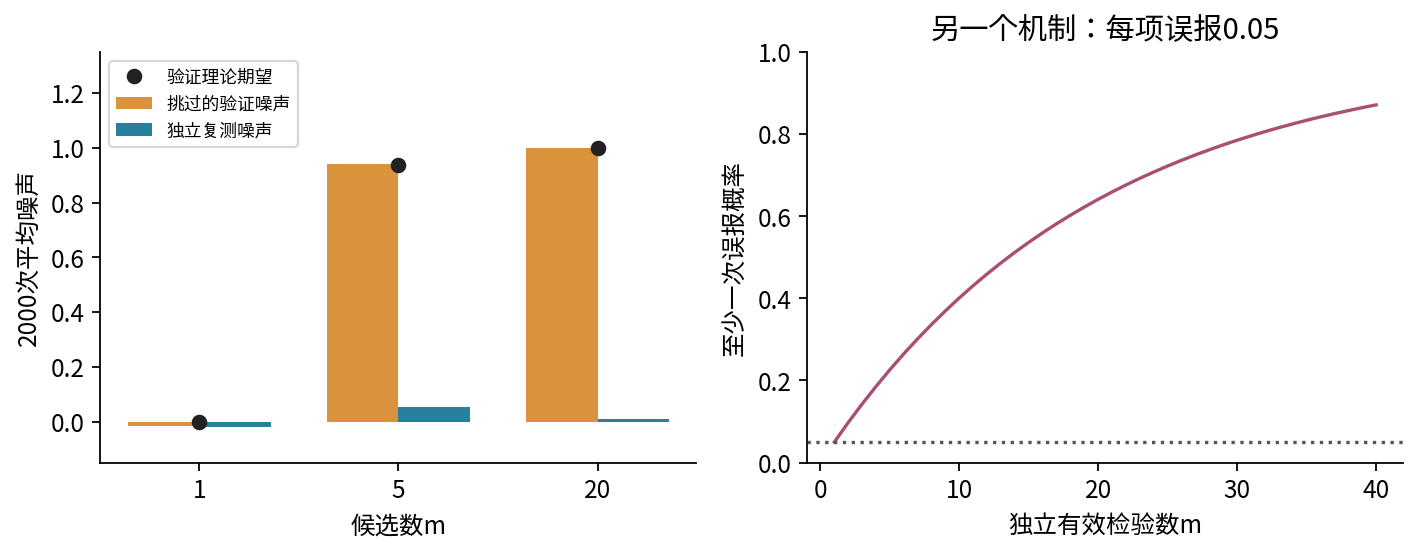

In [11]:
vectors=list(product((-1,1),repeat=3))
assert F(sum(max(v) for v in vectors),8)==F(3,4)
assert sum(t for v in vectors for t in (-1,1))==0
print("selected validation expectation=3/4; independent test expectation=0")
display(Image(filename="figures/08_selection.png",width=750))

## Checks
### 11 错误必须暴露
不能把bool当重复数，不能把自由度7临界值用于两个样本。完整测试还有CSV/配置输出保护。

In [12]:
for call in (lambda:ex.bootstrap_means(d,True,1),lambda:ex.paired_t7([1,2])):
    try:call()
    except ValueError as error:print("rejected",error)
    else:raise AssertionError("invalid input accepted")

rejected bootstrap_repeats: integer in [20,20000] required
rejected table critical value only supports n=8


### 12 五份结果比对
脚本与本Notebook在各自新进程内执行，配置相同才应得到相同结果。

In [13]:
for name in ("results.json","bootstrap.csv","selection.csv","rare_coverage.csv","environment.json"):
    assert (Path("outputs")/name).read_bytes()==(Path("notebook_outputs")/name).read_bytes()
print("5 files byte-identical")

5 files byte-identical


## Next Steps
本表平均差异2个百分点；舍入t与percentile区间并不一致，不能择优报告。把重复单位、抽样假设、原始结果和实际3个百分点门槛一起解释。完成正文14题及实验A至D。

已实际执行真实InProcessKernel，未测试全新Anaconda、浏览器Jupyter、socket内核或跨平台安装；不是GPU/真实模型成绩。来源见lecture.md、source-checks.json。